# Compositional Amortized Inference for Hierarchical Bayesian Models

**References:**
- Arruda et al. (2026) — [Compositional amortized inference for large-scale hierarchical Bayesian models](https://arxiv.org/abs/2505.14429)
- Geffner et al. (2023) — [Compositional score modeling for simulation-based inference](https://proceedings.mlr.press/v202/geffner23a.html)



_Author: Jonas Arruda_

---

## What This Tutorial Covers

Hierarchical Bayesian models are powerful tools in cognitive science and many other fields, but they face a fundamental scalability challenge: inference must be repeated every time data grows — more subjects, more trials, larger studies. Standard amortized inference (training a neural network to approximate the posterior) requires training data that match the exact study size, which makes generalizing to larger datasets difficult.

**Compositional amortized inference** resolves this by decomposing the posterior into pieces that can be independently amortized and then composed at test time — without retraining. The key insight is:

$$p(\boldsymbol{\eta} \mid \mathbf{Y}_{1:J}) \propto p(\boldsymbol{\eta})^{1-J} \prod_{j=1}^{J} p(\boldsymbol{\eta} \mid \mathbf{Y}_j)$$

Each posterior term can be trained using a single network, and then combined via a compositional sampling procedure. This allows a network trained on **small datasets** (e.g., 1 or 5 subjects) to be repurposed for inference over **thousands of subjects** at test time.

### The Example: Hierarchical Evidence Accumulation Model

We use the **Evidence Accumulation Model (EAM)** from mathematical psychology as our running example (see Habermann et al. (2025) — *Amortized Bayesian Multilevel Models*). The EAM is a widely-used model of two-alternative forced-choice reaction time tasks. It captures both response times and choice accuracy in a principled mechanistic framework.

The hierarchical structure has two levels:

| Level | Parameters | Description |
|-------|-----------|-------------|
| **Group** | $\mu_\nu, \mu_{\log\alpha}, \mu_{\log t_0}, \sigma_\nu, \sigma_{\log\alpha}, \sigma_{\log t_0}, \beta$ | Population-level tendencies and variability |
| **Subject** | $\nu_p, \alpha_p, t_{0,p}$ | Individual drift rates, thresholds, and non-decision times |

By the end of this tutorial, you will know how to:
1. Define a hierarchical generative model with BayesFlow
2. Train a `CompositionalDiffusionModel` for group-level parameters
3. Scale inference to 10,000 subjects at test time via `compositional_sample`
4. Recover subject-level parameters via `ancestral_sample`

## 1. Setup and Imports


In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import bayesflow as bf
import keras

import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist, norm as norm_dist

INFO:bayesflow:Using backend 'tensorflow'


In [2]:
# for faster simulations, optional
from numba import njit

## 2. Hierarchical Evidence Accumulation Model (EAM)

### 2.1 The Evidence Accumulation Model

The EAM models a decision as a noisy accumulation of evidence over time. A particle starts at position $\beta \cdot \alpha$ (the relative starting point scaled by the boundary) and drifts with rate $\nu$ and diffusion noise $\sigma \, dW_t$ until it hits either $0$ (lower boundary, choice = 0) or $\alpha$ (upper boundary, choice = 1). The response time is the first-passage time plus a non-decision offset $t_0$ for sensory and motor latency.

The four EAM parameters are:

| Parameter | Symbol | Interpretation |
|-----------|--------|---------------|
| Drift rate | $\nu$ | Speed and direction of evidence accumulation |
| Boundary separation | $\alpha$ | Response caution — larger values mean slower but more accurate responses |
| Non-decision time | $t_0$ | Sensory encoding + motor execution time, not part of decision |
| Starting point | $\beta \in [0,1]$ | Prior bias toward one response option |

The simulation below implements the Euler–Maruyama discretization of this stochastic differential equation. We use `numba` to JIT-compile the inner trial loop to increase simulation speed.

### 2.2 Hierarchical Prior Structure

Subjects are modeled as exchangeable draws from a population. The generative process is:

**Group level** (shared across all subjects):
$$\mu_\nu \sim \mathcal{N}(0.5, 0.3^2), \quad \mu_{\log\alpha} \sim \mathcal{N}(0, 0.05^2), \quad \mu_{\log t_0} \sim \mathcal{N}(-1, 0.3^2)$$
$$\log\sigma_\nu \sim \mathcal{N}(0, 1), \quad \log\sigma_{\log\alpha} \sim \mathcal{N}(0, 1), \quad \log\sigma_{\log t_0} \sim \mathcal{N}(-1, 0.3^2)$$
$$\beta_\text{raw} \sim \mathcal{N}(0, 1), \quad \beta = F^{-1}_{\text{Beta}(50,50)}(\Phi(\beta_\text{raw}))$$

**Subject level** (per-subject draws from the group):
$$\nu_p \sim \mathcal{N}(\mu_\nu, \sigma_\nu^2), \quad \log\alpha_p \sim \mathcal{N}(\mu_{\log\alpha}, \sigma_{\log\alpha}^2), \quad \log t_{0,p} \sim \mathcal{N}(\mu_{\log t_0}, \sigma_{\log t_0}^2)$$

The starting point $\beta$ is shared across subjects (a global bias), while drift rate and thresholds vary. Log-normal priors on $\alpha$ and $t_0$ ensure positivity without truncation.

The `beta_raw` reparameterization maps an unconstrained Gaussian to the $[0,1]$ Beta-distributed prior via the probability integral transform.

In [3]:
@njit
def simulate_ddm_trial(nu, alpha, t0, beta, dt=1e-3, scale=1.0, max_time=10.0):
    """
    Simulates one realization of the diffusion process given
    a set of parameters and a step size `dt`.

    Returns:
    --------
    (x, c) - a tuple of response time (y - float) and a
        binary decision (c - int)
    """

    # Inits (process starts at relative starting point)
    y = beta * alpha
    rt = t0
    const = scale * np.sqrt(dt)

    # Loop through process and check boundary conditions
    while (alpha >= y >= 0) and rt <= max_time:
        # Perform diffusion equation
        z = np.random.randn()
        y += nu * dt + const * z

        # Increment step counter
        rt += dt

    if y >= alpha:
        c = 1.0
    else:
        c = 0.0
    return c, rt


def simulate_ddm(nu, alpha, t0, beta, n_subjects=1, n_trials=1):
    if isinstance(nu, (float, int)):
        nu = np.ones((n_subjects,)) * nu
        alpha = np.ones((n_subjects,)) * alpha
        t0 = np.ones((n_subjects,)) * t0
    data = np.zeros((n_subjects, n_trials, 2))
    for j_subject in range(n_subjects):
        for i_trial in range(n_trials):
            data[j_subject, i_trial] = simulate_ddm_trial(nu[j_subject], alpha[j_subject], t0[j_subject], beta)
    if n_subjects == 1 and n_trials == 1:
        data = data[0, 0]
    elif n_subjects == 1:
        data = data[0]
    elif n_trials == 1:
        data = data[:, 0]
    return dict(sim_data=data)

In [4]:
def score_log_norm(x, m, s):
    return -(x-m) / s**2


def beta_from_normal(z, a, b):
    u = norm_dist.cdf(z)
    x = beta_dist.ppf(u, a, b)  # Beta inverse CDF
    return x


global_prior = {
    'mu_nu': (0.5, 0.3),
    'mu_alpha': (0.0, 0.05),
    'mu_t0': (-1.0, 0.3),
    'log_sigma_nu': (-1.0, 1.0),
    'log_sigma_alpha': (-3.0, 1.0),
    'log_sigma_t0': (-1.0, 0.3),
    'beta_raw': (0.0, 1.0),
}

def sample_hierarchical_priors(n_subjects=1):
    """
    Returns a dict with group params and per subject params.
    """
    # Group level
    mu_nu = np.random.normal(global_prior["mu_nu"][0], global_prior["mu_nu"][1])
    mu_alpha = np.random.normal(global_prior["mu_alpha"][0], global_prior["mu_alpha"][1])
    mu_t0 = np.random.normal(global_prior["mu_t0"][0], global_prior["mu_t0"][1])

    log_sigma_nu = np.random.normal(global_prior["log_sigma_nu"][0], global_prior["log_sigma_nu"][1])
    log_sigma_alpha = np.random.normal(global_prior["log_sigma_alpha"][0], global_prior["log_sigma_alpha"][1])
    log_sigma_t0 = np.random.normal(global_prior["log_sigma_t0"][0], global_prior["log_sigma_t0"][1])

    beta_raw = np.random.normal(global_prior["beta_raw"][0], global_prior["beta_raw"][1])
    beta = beta_from_normal(beta_raw, a=50, b=50)

    # Subject level
    nu = np.random.normal(mu_nu, np.exp(log_sigma_nu), size=n_subjects)
    alpha = np.exp(np.random.normal(mu_alpha, np.exp(log_sigma_alpha), size=n_subjects))
    t0 = np.exp(np.random.normal(mu_t0, np.exp(log_sigma_t0), size=n_subjects))

    return {
        # group
        "mu_nu": mu_nu,
        "mu_alpha": mu_alpha,
        "mu_t0": mu_t0,
        "log_sigma_nu": log_sigma_nu,
        "log_sigma_alpha": log_sigma_alpha,
        "log_sigma_t0": log_sigma_t0,
        "beta_raw": beta_raw,
        "beta": beta,
        # subjects
        "nu": nu,
        "alpha": alpha,
        "t0": t0,
    }

### 2.3 The Prior Score Function

Compositional inference requires the **score function** of the prior, i.e., $\nabla_\theta \log p(\theta)$. For a Gaussian prior $\mathcal{N}(\mu, \sigma^2)$, the score is simply:
$$\nabla_x \log p(x) = -\frac{x - \mu}{\sigma^2}$$

The score is time-weighted by $(1 - t)$ following the diffusion bridge formulation in Arruda et al. (2026), where $t \in [0, 1]$ is the diffusion time. At $t=0$ (start of diffusion) the prior score has full weight; at $t=1$ (end) it vanishes.

In [5]:
def prior_global_score(x: dict[str, np.ndarray], time: np.ndarray) -> dict[str, np.ndarray]:
    mu_nu = x["mu_nu"]
    mu_alpha = x["mu_alpha"]
    mu_t0 = x["mu_t0"]
    log_sigma_nu = x["log_sigma_nu"]
    log_sigma_alpha = x["log_sigma_alpha"]
    log_sigma_t0 = x["log_sigma_t0"]
    beta_raw = x["beta_raw"]

    parts = {
        "mu_nu": (1-time) * score_log_norm(mu_nu, m=global_prior["mu_nu"][0], s=global_prior["mu_nu"][1]),
        "mu_alpha": (1-time) * score_log_norm(mu_alpha, m=global_prior["mu_alpha"][0], s=global_prior["mu_alpha"][1]),
        "mu_t0": (1-time) * score_log_norm(mu_t0, m=global_prior["mu_t0"][0], s=global_prior["mu_t0"][1]),
        "log_sigma_nu": (1-time) * score_log_norm(log_sigma_nu, m=global_prior["log_sigma_nu"][0], s=global_prior["log_sigma_nu"][1]),
        "log_sigma_alpha": (1-time) * score_log_norm(log_sigma_alpha, m=global_prior["log_sigma_alpha"][0], s=global_prior["log_sigma_alpha"][1]),
        "log_sigma_t0": (1-time) * score_log_norm(log_sigma_t0, m=global_prior["log_sigma_t0"][0], s=global_prior["log_sigma_t0"][1]),
        "beta_raw": (1-time) * score_log_norm(beta_raw, m=global_prior["beta_raw"][0], s=global_prior["beta_raw"][1]),
    }
    return parts

In [6]:
simulator_hierarchical = bf.make_simulator([sample_hierarchical_priors, simulate_ddm])
simulator_hierarchical.sample(10)['sim_data']

array([[1.        , 0.71087643],
       [1.        , 0.32586295],
       [0.        , 0.65258866],
       [1.        , 0.56785688],
       [1.        , 0.74872884],
       [1.        , 0.41415553],
       [1.        , 0.73329022],
       [0.        , 0.56402845],
       [0.        , 0.80291146],
       [0.        , 0.51513243]])

## 3. Configuration

We set all hyperparameters in one place for easy experimentation.

> **Note on training vs. test scale:** The network sees only 5 subjects per training sample during training (small enough for fast simulation). At inference time, compositional sampling decomposes the 10,000-subject problem into 5-subject sub-problems, aggregates their posterior scores, and samples from the composed posterior without any retraining.

In [7]:
N_TRAINING_BATCHES = 256
BATCH_SIZE = 64
EPOCHS = 1_000
N_LOCAL_SUBJECTS = 5  # number of subjects in a single training batch

N_TRIALS = 30         # trials per subject
N_SUBJECTS = 10_000   # number of subjects in one experiment
N_TEST = 100          # number of test data sets
N_SAMPLES = 100       # posterior samples per test dataset

## 4. Building the BayesFlow Workflows

We need two workflows, one for each level of the hierarchy:

### 4.1 Global Workflow (Group-level Parameters)

**Summary network**: Each subject's trial data is an unordered set of (choice, RT) pairs. The `SetTransformer` is a permutation-invariant attention-based architecture that produces a fixed-size embedding.

**Inference network**: The `DiffusionModel` is the key component enabling compositional inference. It learns to approximate the per-subject posterior score $\nabla_{\boldsymbol{\eta}_t} \log p({\boldsymbol{\eta}_t} \mid \mathbf{Y}_j)$ using a diffusion-based score model. During training this is just a standard Diffusion Model (see our [Diffusion Model Tutorial](Diffusion_Models.ipynb)). At inference time, scores from many individuals are summed and integrated via an SDE solver to produce samples from the composed posterior.

### 4.2 Local Workflow (Subject-level Parameters)

The local workflow recovers per-subject parameters $(\nu_p, \alpha_p, t_{0,p})$ given the individual subject's data and conditioned on the group-level posterior. During training it gets the true global parameters and during inference we can sample from the local parameters using ancestral sampling.

After training, both workflows are ready for compositional and ancestral sampling respectively.

In [8]:
param_names_global = list(global_prior.keys())
pretty_param_names_global = [
    r'$\mu_\nu$', r'$\mu_\alpha$', r'$\mu_{t_0}$',
    r'$\log \sigma_\nu$', r'$\log \sigma_\alpha$', r'$\log \sigma_{t_0}$',
    r'$\beta_\text{raw}$'
]

# Global (group-level) workflow
adapter = (
    bf.adapters.Adapter()
    .to_array()
    .convert_dtype("float64", "float32")
    .concatenate(param_names_global, into="inference_variables")
    .rename("sim_data", "summary_variables")
)

workflow_global = bf.CompositionalWorkflow(
    adapter=adapter,
    summary_network=bf.networks.SetTransformer(summary_dim=16),
    inference_network=bf.networks.DiffusionModel(),
)

# note: you can also turn a BasicWorkflow into a compositional one including the already trained diffusion model
# from bayesflow.workflows import compositional_workflow_from_basic
# workflow_global = compositional_workflow_from_basic(workflow_global)

In [9]:
param_names_local = ['nu', 'alpha', 't0']
pretty_param_names_local = [r'$\nu_p$', r'$\alpha_p$', r'$t_{0,p}$']

# Local (subject-level) workflow
adapter_local = (
    bf.adapters.Adapter()
    .to_array()
    .convert_dtype("float64", "float32")
    .log(["alpha", "t0"])
    .concatenate(param_names_local, into="inference_variables")
    .concatenate(param_names_global, into="inference_conditions")
    .rename("sim_data", "summary_variables")
)

workflow_local = bf.BasicWorkflow(
    adapter=adapter_local,
    summary_network=bf.networks.SetTransformer(summary_dim=16),
    inference_network=bf.networks.StableConsistencyModel(),
)

In [ ]:
# The SetTransformer treats all 5 * N_TRIALS (choice, RT) pairs from all subjects as a single unordered set.
training_data = simulator_hierarchical.sample_parallel(
    (N_TRAINING_BATCHES * BATCH_SIZE),
    n_subjects=N_LOCAL_SUBJECTS, n_trials=N_TRIALS
)
training_data['sim_data'] = training_data['sim_data'].reshape(
    (N_TRAINING_BATCHES * BATCH_SIZE, N_LOCAL_SUBJECTS * N_TRIALS, 2)
)

history = workflow_global.fit_offline(
    training_data,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)
# keras.saving.save_model(workflow_global.approximator, "misc/diffusion/partial_pooling_global.keras")
# workflow_global.approximator = keras.saving.load_model("misc/diffusion/partial_pooling_global.keras")

In [ ]:
# The SetTransformer treats all N_TRIALS (choice, RT) pairs as a single unordered set.
training_data = simulator_hierarchical.sample_parallel(
    (N_TRAINING_BATCHES * BATCH_SIZE),
    n_trials=N_TRIALS
)

history = workflow_local.fit_offline(
    training_data,
    epochs=50,
    batch_size=BATCH_SIZE,
)
# keras.saving.save_model(workflow_local.approximator, "misc/diffusion/partial_pooling_local.keras")
# workflow_local.approximator = keras.saving.load_model("misc/diffusion/partial_pooling_local.keras")

We first validate that the trained global workflow can recover parameters on test datasets of the same scale (5 subjects, 30 trials each). This is a sanity check to ensure the network learned something sensible before we attempt to scale up to 10,000 subjects. At this stage, you should continue only with a well calibrated model. Recovery might not be perfect due to the smaller number of trials.

In [12]:
test_data_single = simulator_hierarchical.sample_parallel(
    N_TEST, n_subjects=N_LOCAL_SUBJECTS, n_trials=N_TRIALS
)
test_data_single['sim_data'] = test_data_single['sim_data'].reshape((
    N_TEST, N_LOCAL_SUBJECTS * N_TRIALS, 2)
)

test_posterior = workflow_global.sample(
    num_samples=N_SAMPLES,
    conditions={'sim_data': test_data_single['sim_data']},
    batch_size=BATCH_SIZE,
)

Summarizing:   0%|          | 0/2 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/2 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 30.68 seconds.


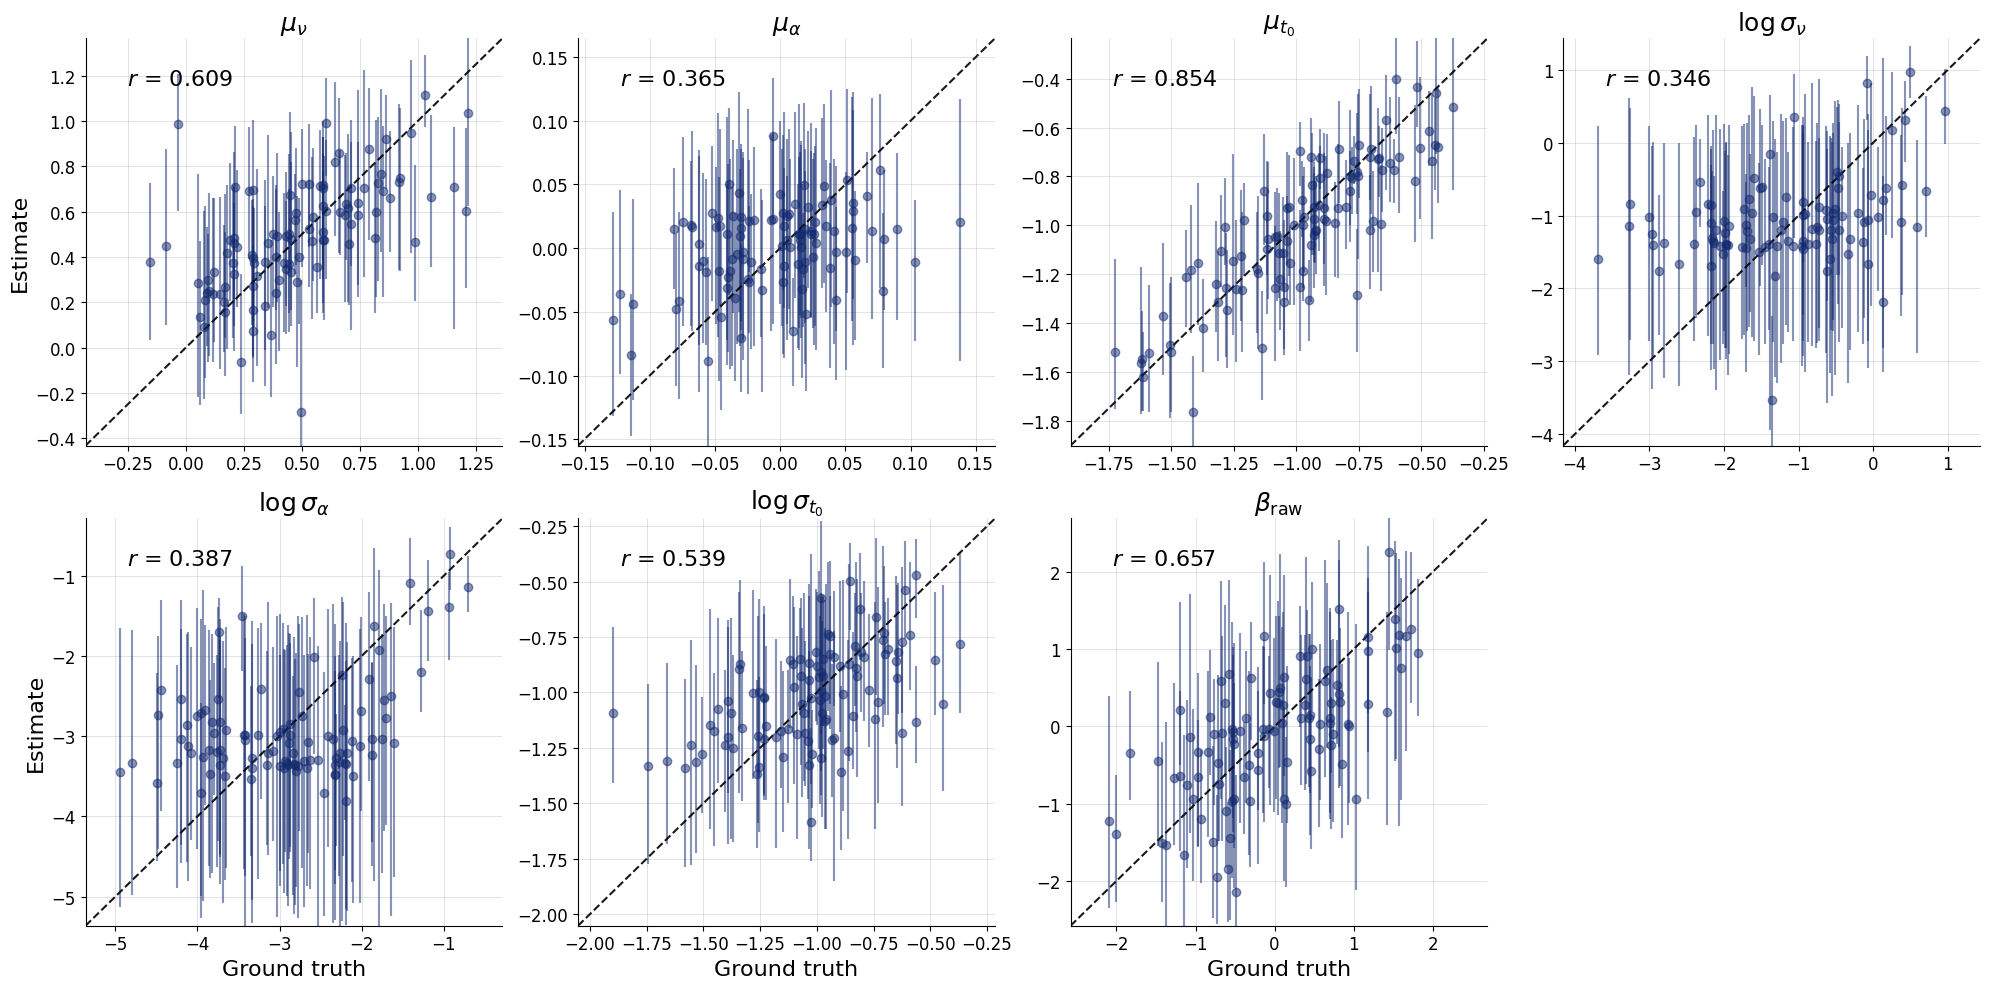

In [13]:
fig = bf.diagnostics.recovery(
    estimates=test_posterior,
    targets=test_data_single,
    variable_names=pretty_param_names_global
)

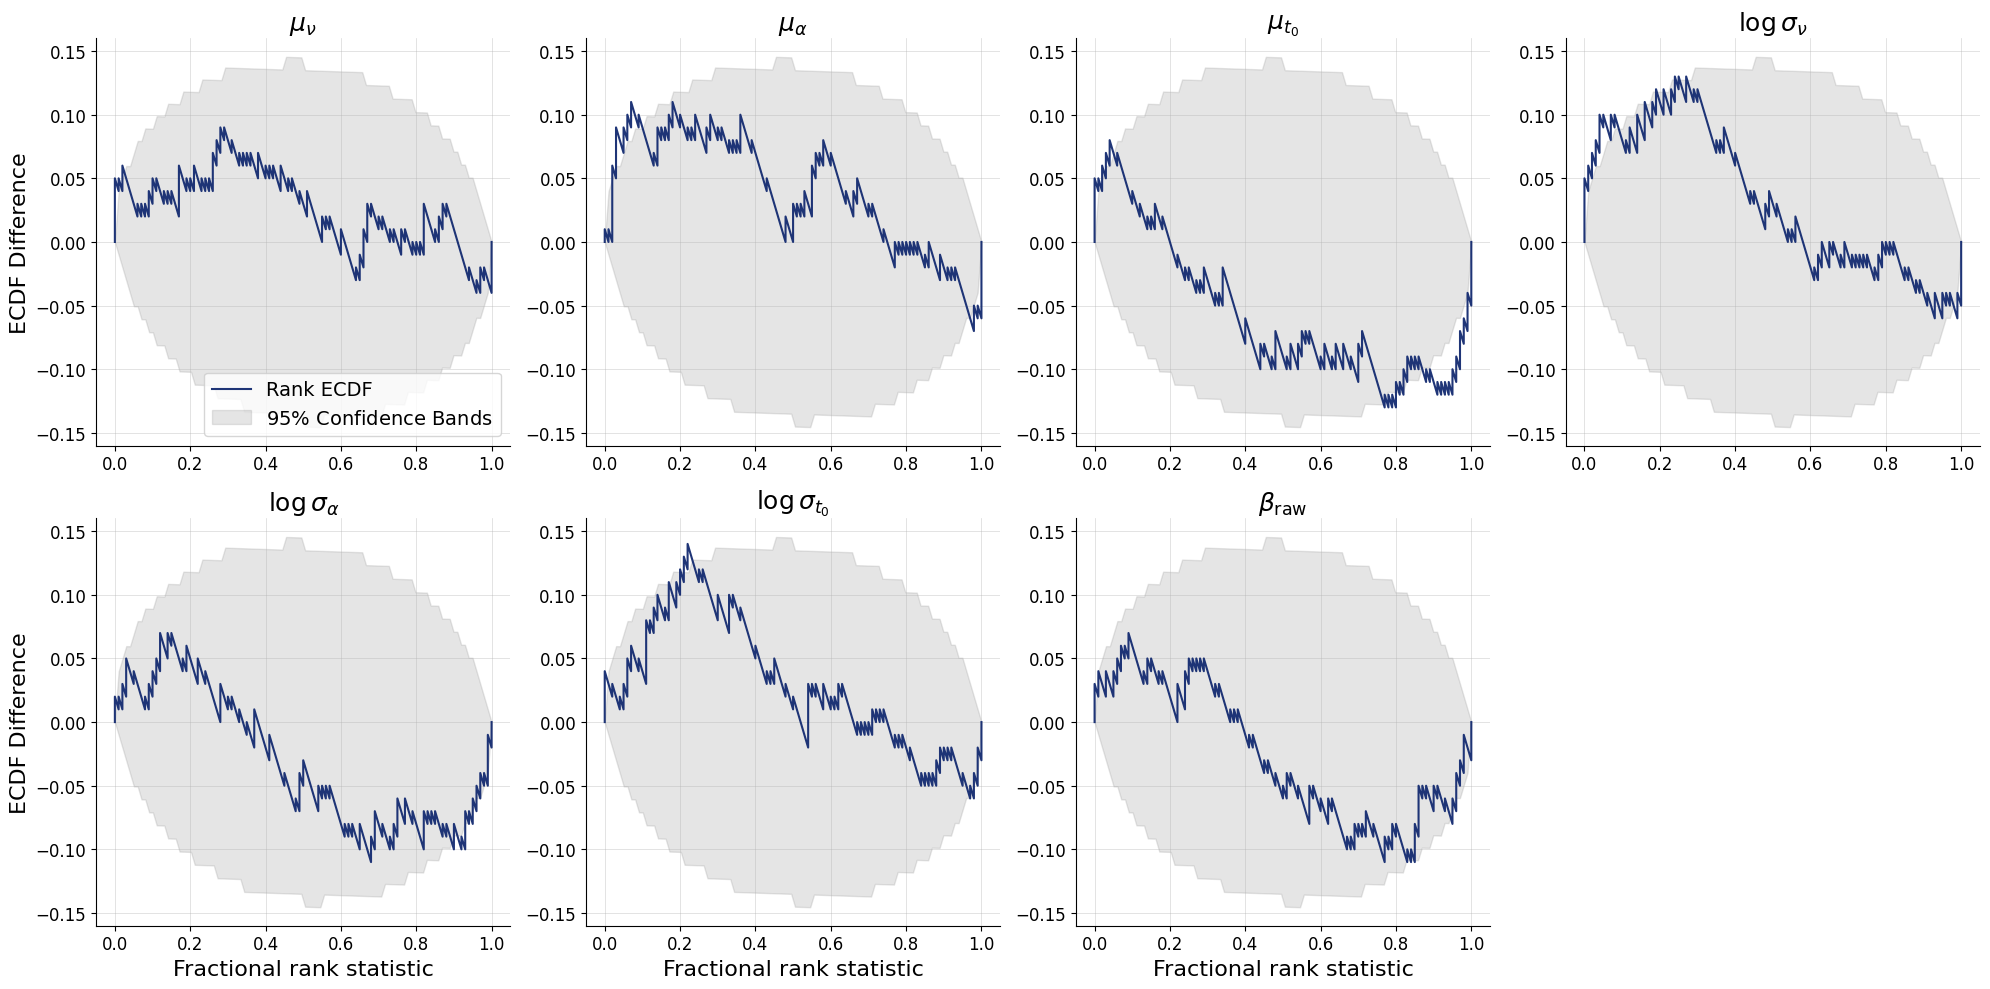

In [14]:
fig = bf.diagnostics.calibration_ecdf(
    estimates=test_posterior,
    targets=test_data_single,
    variable_names=pretty_param_names_global
)

## 5. Compositional Inference at Scale

This is where the method's scalability shines. We now simulate `N_TEST` independent studies, each with **10,000 subjects** — 2000× more subjects than the network ever saw during training.

In [15]:
test_data = simulator_hierarchical.sample_parallel(
    N_TEST, n_subjects=N_SUBJECTS, n_trials=N_TRIALS
)
# bring the data in the right format
test_data['sim_data'] = test_data['sim_data'].reshape((
    N_TEST, N_SUBJECTS // N_LOCAL_SUBJECTS, N_TRIALS * N_LOCAL_SUBJECTS, 2)
)
summaries = None  # will be computed later by the workflow

### How Compositional sampling works

Instead of passing all 10,000 subjects at once (which the network was not trained for), `compositional_sample` partitions subjects into mini-batches of `M=mini_batch_size`. For each mini-batch, the trained `CompositionalDiffusionModel` evaluates the approximate posterior score contributions and then the total score is:
$$\nabla_{\boldsymbol{\eta}} \log p_t(\boldsymbol{\eta} \mid \mathbf{Y}_{1:J}) = d(t) \cdot \bigl[(1-t)(1-J) \nabla_{\boldsymbol{\eta}} \log p(\theta) + \frac{J}{M}\sum_{m=1}^{M} \hat{s}_m(\boldsymbol{\eta} \mid \mathbf{Y}_m)\bigr]$$

This summed score is then used by a diffusion solver.

Key arguments:
- `compute_prior_score` — injects the analytically known prior score into the solver
- `mini_batch_size` — number of subjects processed per score evaluation (trades memory for accuracy)
- `return_summaries` — cache computed subject summaries so they don't need to be recomputed across subsequent calls with different sampler hyperparameters

The compositional sampling accumulates scores from all 10,000 subjects, hence it also accumulates errors. The `compositional_bridge_d1` and `compositional_bridge_d0` arguments can help with calibration of the posterior by scaling the score over time. This is the exponential function
from Arruda et al. (2026) that smoothly transitions from `compositional_bridge_d1` at time 1 to `compositional_bridge_d0` at time 0. Setting both to the same value (e.g., 0.1) applies a constant scaling factor.

Summarizing:   0%|          | 0/313 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 23.38 minutes.


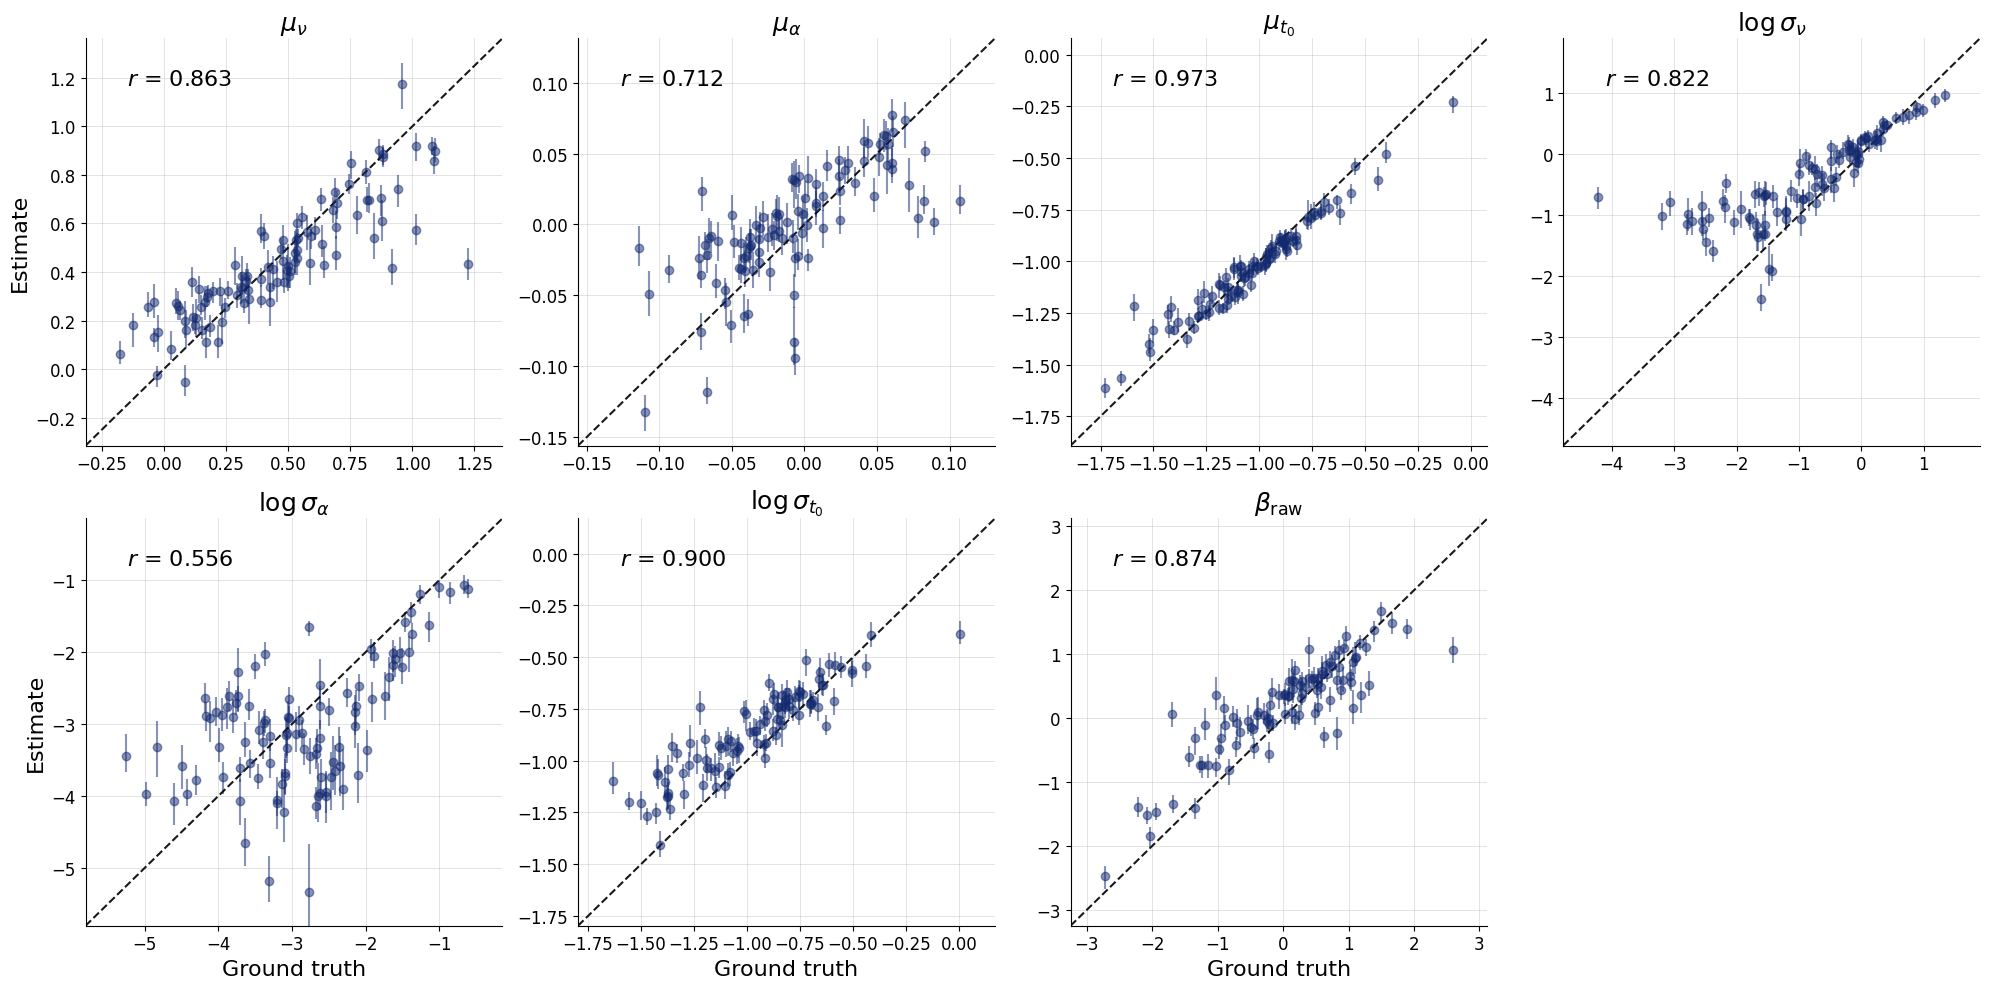

In [16]:
global_posterior = workflow_global.compositional_sample(
    num_samples=N_SAMPLES,
    conditions={'sim_data': test_data['sim_data']}, # get rid of all unnecessary keys
    compute_prior_score=prior_global_score,
    #compositional_bridge_d1=0.1,     # hyperparameter, control error accumulation
    #compositional_bridge_d0=0.1,     # hyperparameter, control error accumulation
    method='two_step_adaptive',       # hyperparameter, try "euler_maruyama" for non-adaptive method
    steps='adaptive',                 # hyperparameter, speed vs accuracy/stability
    mini_batch_size=10,               # hyperparameter, memory/speed vs accuracy
    batch_size=BATCH_SIZE*10,
    return_summaries=True,
    summaries=summaries,
)
summaries = global_posterior.pop("_summaries")  # when rerunning with different sampler hyperparameters, pass these summaries back in to avoid recomputing them

fig = bf.diagnostics.recovery(
    estimates=global_posterior,
    targets=test_data,
    variable_names=pretty_param_names_global
)
plt.show()

We also provide a stabilized implementation of the approximation algorithm by Linhart et al. (2026) with the mini-batching from Arruda et al. (2026). This is based on a Gaussian approximation of the reverse diffusion kernel using the Jacobian of the score (and hence, it is computationally more costly). The method needs access to the noisy prior corresponding to the noise schedule (which you can provide or be computed directly from the diffusion model, leading to an additional pass through the network in each step of the solver). Just set `use_jac=True` and provide the corresponding `compute_prior_score`. This method can improve calibration, if the number of conditions is small, at the cost of increased computation time during inference. We recommend to use a simple ODE solver here and use it only for small numbers of compositions (e.g., <50).

In [ ]:
noise_schedule = workflow_global.approximator.inference_network.noise_schedule

def score_log_norm_noisy(x, m, s, alpha_t, sigma_t):
    return -(x-alpha_t * m) / ((alpha_t*s)**2 + sigma_t**2)

def prior_global_score_jac(x: dict[str, np.ndarray], time: np.ndarray) -> dict[str, np.ndarray]:
    # diffused prior for backward kernel: N(alpha_t x theta_0, sigma_t**2 I)
    log_snr_t = noise_schedule.get_log_snr(t=time, training=False)
    alpha_t, sigma_t = noise_schedule.get_alpha_sigma(log_snr_t=log_snr_t)

    mu_nu = x["mu_nu"]
    mu_log_alpha = x["mu_log_alpha"]
    mu_log_t0 = x["mu_log_t0"]
    log_sigma_nu = x["log_sigma_nu"]
    log_sigma_log_alpha = x["log_sigma_log_alpha"]
    log_sigma_log_t0 = x["log_sigma_log_t0"]
    beta_raw = x["beta_raw"]

    parts = {
        "mu_nu": score_log_norm_noisy(mu_nu, m=0.5, s=0.3, alpha_t=alpha_t, sigma_t=sigma_t),
        "mu_log_alpha": score_log_norm_noisy(mu_log_alpha, m=0.0, s=0.05, alpha_t=alpha_t, sigma_t=sigma_t),
        "mu_log_t0": score_log_norm_noisy(mu_log_t0, m=-1.0, s=0.3, alpha_t=alpha_t, sigma_t=sigma_t),
        "log_sigma_nu": score_log_norm_noisy(log_sigma_nu, m=0.0, s=1.0, alpha_t=alpha_t, sigma_t=sigma_t),
        "log_sigma_log_alpha": score_log_norm_noisy(log_sigma_log_alpha, m=0.0, s=1.0, alpha_t=alpha_t, sigma_t=sigma_t),
        "log_sigma_log_t0": score_log_norm_noisy(log_sigma_log_t0, m=-1.0, s=0.3, alpha_t=alpha_t, sigma_t=sigma_t),
        "beta_raw": score_log_norm_noisy(beta_raw, m=0.0, s=1.0, alpha_t=alpha_t, sigma_t=sigma_t),
    }
    return parts

global_posterior = workflow_global.compositional_sample(
    num_samples=N_SAMPLES,
    conditions={'sim_data': test_data['sim_data']}, # get rid of all unnecessary keys
    compute_prior_score=prior_global_score_jac,
    method='euler',
    steps=50,
    mini_batch_size=10,
    batch_size=BATCH_SIZE,
    summaries=summaries,
    use_jac=True
)

## 6. Subject-Level Inference via Ancestral Sampling

With group-level posteriors in hand, we can now recover the per-subject parameters $(\nu_p, \alpha_p, t_{0,p})$ for all 10,000 subjects.

### Ancestral sampling

`ancestral_sample` implements the second stage of the hierarchical inference cascade: For each posterior draw of the global parameters from `global_posterior`, the local workflow conditions on that draw and the individual subject's trials to produce a subject-level sample. This naturally propagates uncertainty from the group level down to the individual level.

The `ancestral_conditions` gets the global samples as conditioning variables
The result is a full approximate joint posterior over all parameters at both levels of the hierarchy.

In [17]:
# only check for N_LOCAL_CONDITIONS local conditions per dataset here
N_LOCAL_CONDITIONS = 10
smaller_test_data = {k: v[:, :N_LOCAL_CONDITIONS] for k, v in test_data.items() if k in param_names_local}
smaller_test_data['sim_data'] = test_data['sim_data'].reshape(N_TEST, N_SUBJECTS, N_TRIALS, 2)[:, :N_LOCAL_CONDITIONS]

In [18]:
local_posterior = workflow_local.ancestral_sample(
    conditions={'sim_data': smaller_test_data['sim_data']},
    ancestral_conditions=global_posterior,
    batch_size=BATCH_SIZE*N_SAMPLES,
)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/16 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 12.78 seconds.


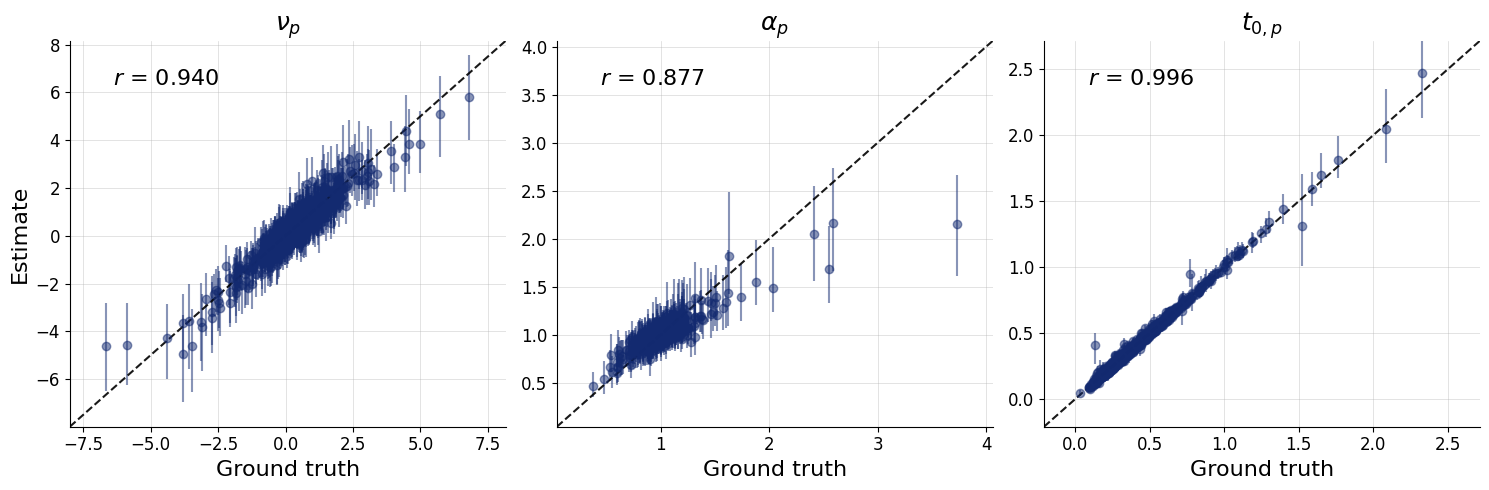

In [19]:
flat_local_posterior = {k: v.reshape(N_TEST*N_LOCAL_CONDITIONS, N_SAMPLES, 1) for k, v in local_posterior.items()}
flat_test_data = {k: v.reshape(N_TEST*N_LOCAL_CONDITIONS, 1) for k, v in smaller_test_data.items() if not k == 'sim_data'}

fig = bf.diagnostics.recovery(
    estimates=flat_local_posterior,
    targets=flat_test_data,
    variable_names=pretty_param_names_local,
)

Congratulations! You have now run a full compositional amortized inference pipeline on a hierarchical Bayesian model with 10,000 subjects!